<img src='./img/thrivegeo_logo_with_font.png' width="15%" style="float: right">
<br>


<center><h1> 🌊 Monitoreo de Olas de Calor en las Costas de España 🌡️ </h1></center>


<a id="example1"></a>

## Introducción

El mar Mediterráneo se está calentando al doble de la velocidad del océano global, lo que le ha valido la reputación de ser un punto crítico de olas de calor marinas.<br>

El mar Balear, una subcuenca del Mediterráneo occidental, representa un centro ecológico y económico vital: sus aguas albergan extensas praderas de *Posidonia oceanica* (sumideros de carbono cruciales), constituyen zonas clave de desove para el atún rojo del Atlántico (*Thunnus thynnus*) y sustentan una próspera actividad pesquera artesanal. También constituye un hábitat clave para el mejillón abanico mediterráneo (*Pinnus nobilis*), una especie en peligro crítico de extinción.

En los últimos años, las severas olas de calor marinas (MHW, por sus siglas en inglés) de verano han provocado una mortalidad masiva generalizada de invertebrados bentónicos, han alterado las redes tróficas pelágicas y han interrumpido el rendimiento de la pesca local. Si bien las plataformas de visualización globales como [**My Ocean Health** portal](https://myoceanhealth.marine.copernicus.eu/en) de Copernicus ofrecen una excelente visión general de alto nivel, su representación poco precisa y las limitaciones de zoom dificultan las evaluaciones regionales detalladas.

En este tutorial, exploraremos cómo ir más allá de los visores web estándar y cómo utilizar las herramientas contenidas en la [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction).

### Al finalizar este tutorial, serás capaz de...
🔌 acceder a los datos a través de la **Python API** de `copernicusMarine` y `xarray`.<br>
🐍 extraer programáticamente datos de temperatura superficial del mar (SST) de alta resolución sobre un área de interés.<br>
🗺️ generar mapas personalizados de las categorías diarias y mensuales de MHW.

### Secciones del Notebook
* [Introducción](#example1)
* [1️⃣ : Exploración del Catálogo](#example2)
* [2️⃣ : Monitoreo de Olas de Calor Marinas (MHW)](#example3)
* [3️⃣ : Ahora es tu turno](#example4)
* [4️⃣ : Conclusión](#example5)

<hr>

### Módulos de Python

| Nombre de la librería | Descripción |
| :---: | :---|
| **copernicusmarine** |[Copernicusmarine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) interactúa con el Copernicus Marine Data Store para explorar metadatos y recuperar datos de cualquier tipo de producto: modelos numéricos, observaciones satelitales y/o in situ. |
| **xarray** | [Xarray](http://xarray.pydata.org/en/stable/) es una biblioteca que facilita la manipulación de archivos NetCDF dentro de Python. Introduce etiquetas en forma de dimensiones, coordenadas y atributos sobre matrices sin procesar (similares a las de **NumPy**), lo que permite una experiencia de desarrollo más intuitiva, concisa y con menos errores. |
| **cartopy** |[Cartopy](https://scitools.org.uk/cartopy/docs/latest/) es una biblioteca para trazar mapas y realizar análisis de datos geoespaciales en Python. |

In [1]:
import copernicusmarine
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Funciones personalizadas

In [2]:
def available_products(catalogue_search):

    products_summary = []
    for product in catalogue_search.products:
        products_summary.append({
            "Product Title": product.title,
            "Product ID": product.product_id,
            "Sources": ", ".join(product.sources) if product.sources else "N/A",
            "Number of Datasets": len(product.datasets),
            # "Datasets": product.datasets
        })

    df_products = pd.DataFrame(products_summary)
    return df_products

In [3]:
def available_datasets(product_ret):
    prod_ids = []
    variables_per_prod=[]
    for prod in range(len(product_ret.products)):
        for data_s in range(len(product_ret.products[prod].datasets)):
            prod_ids.append(product_ret.products[prod].datasets[data_s].dataset_id)
            int_var = []
            for variable in range(len(product_ret.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables)):
                int_var.append(product_ret.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables[variable].standard_name)
            variables_per_prod.append(int_var)

    return [prod_ids,variables_per_prod]

### Credenciales de acceso

Para acceder al Catálogo de Copernicus Marine, es necesario crear una cuenta y un **archivo de configuración**.

Puedes serguir [éste tutorial](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration). Dicha configuración solo se debe hacer una vez.

<a id="example2"></a>

## 1️⃣ : Exploración del Catálogo

El Copernicus Marine Data Store alberga 307 productos disponibles para el público a través de su portal en línea. Como ya se ha explicado anteriormente, podemos acceder a los datos a través de su interfaz web. Si bien podemos explorar los conjuntos de datos visualmente a través de la interfaz web, también podemos descubrirlos y filtrarlos mediante programación utilizando la biblioteca `copernicusmarine` de Python.

Una vez que hayamos importado los módulos necesarios e inicializado nuestras credenciales, accederemos al catálogo utilizando la función `describe()`. Esto devuelve un **Pydantic `BaseModel`** que contiene todos los campos de metadatos.

In [4]:
# Cargamos el catálogo
catalogue = copernicusmarine.describe()


Fetching catalogue 1: 100%|██████████| 2/2 [00:11<00:00,  5.11s/it]

Al inspeccionar el primer elemento, vemos una respuesta estructurada que detalla los activos disponibles:

In [5]:
catalogue.products[0]

CopernicusMarineProduct(title='Antarctic Sea Ice Extent from Reanalysis', product_id='ANTARCTIC_OMI_SI_extent', thumbnail_url='https://documentation.marine.copernicus.eu/IMG/ANTARCTIC_OMI_SI_extent.png', description='**DEFINITION**\n\nEstimates of Antarctic sea ice extent are obtained from the surface of oceans grid cells that have at least 15% sea ice concentration. These values are cumulated in the entire Southern Hemisphere (excluding ice lakes) and from 1993 up to real time aiming to:\ni) obtain the Antarctic sea ice extent as expressed in millions of km squared (106 km2) to monitor both the large-scale variability and mean state and change.\nii) to monitor the change in sea ice extent as expressed in millions of km squared per decade (106 km2/decade), or in sea ice extent loss/gain since the beginning of the time series as expressed in percent per decade (%/decade; reference period being the first date of the key figure b) dot-dashed trend line, Vaughan et al., 2013)). For the Sou

Para inspeccionar fácilmente estos metadatos, convertimos el `BaseModel` en un marco de datos, para tener una idea de lo que contiene cada uno de los productos, como por ejemplo:

- Títutlo del producto
- ID del producto
- Origen
- Número de datasets disponibles

In [6]:
#  extraemos informacion de primer nivel
products_summary = []
for product in catalogue.products:
    products_summary.append({
        "Product Title": product.title,
        "Product ID": product.product_id,
        "Sources": ", ".join(product.sources) if product.sources else "N/A",
        "Number of Datasets": len(product.datasets)
    })

df_products = pd.DataFrame(products_summary)

# exploramos los datos obtenidos
print(f"Total Products Available: {len(df_products)}")
df_products

Total Products Available: 307


,Product Title,Product ID,Sources,Number of Datasets
0,Antarctic Sea Ice Extent from Reanalysis,ANTARCTIC_OMI_SI_extent,Numerical models,1
1,Antarctic Monthly Sea Ice Extent from Observat...,ANTARCTIC_OMI_SI_extent_obs,Satellite observations,1
2,Arctic Ocean Biogeochemistry Analysis and Fore...,ARCTIC_ANALYSISFORECAST_BGC_002_004,Numerical models,2
3,Arctic Ocean Physics Analysis and Forecast,ARCTIC_ANALYSISFORECAST_PHY_002_001,Numerical models,4
4,Arctic Ocean Sea Ice Analysis and Forecast,ARCTIC_ANALYSISFORECAST_PHY_ICE_002_011,Numerical models,2
...,...,...,...,...
302,Global Ocean Daily Gridded Sea Surface Winds f...,WIND_GLO_PHY_L3_NRT_012_002,Satellite observations,36
303,Global Ocean Hourly Reprocessed Sea Surface Wi...,WIND_GLO_PHY_L4_MY_012_006,"Numerical models, Satellite observations",2
304,Global Ocean Hourly Sea Surface Wind and Stres...,WIND_GLO_PHY_L4_NRT_012_004,"Numerical models, Satellite observations",1
305,High-resolution L3 Sea Surface Wind from MY Sa...,WIND_MED_PHY_HR_L3_MY_012_109,Satellite observations,4


El catálogo también nos permite buscar en base a expresiones clave. Estamos interesados en explorar datos que se relacionen con el Mar Mediterráneo (**Mediterranean Sea**)

In [7]:
heat_cat = copernicusmarine.describe(contains=["Mediterranean Sea"])

Fetching catalogue 1: 100%|██████████| 2/2 [00:11<00:00,  5.88s/it] 


Dado que nuestra área objetivo es el mar Mediterráneo, hemos creado una función auxiliar personalizada, `available_products`, para filtrar automáticamente los metadatos de los productos de nivel superior. Mediante esta función, identificamos 43 de los 307 productos específicos del **mar Mediterráneo**.

In [8]:
datasets_s = available_products(heat_cat)
datasets_s

,Product Title,Product ID,Sources,Number of Datasets
0,Black Sea Physics Analysis and Forecast,BLKSEA_ANALYSISFORECAST_PHY_007_001,Numerical models,30
1,Mediterrranean Outflow Water Index from Reanal...,IBI_OMI_WMHE_mow,"In-situ observations, Numerical models",4
2,Mediterranean Sea- In-Situ Near Real Time Obse...,INSITU_MED_PHYBGCWAV_DISCRETE_MYNRT_013_035,In-situ observations,1
3,Mediterranean Sea Biogeochemistry Analysis and...,MEDSEA_ANALYSISFORECAST_BGC_006_014,Numerical models,13
4,Mediterranean Sea Physics Analysis and Forecast,MEDSEA_ANALYSISFORECAST_PHY_006_013,Numerical models,25
5,Mediterranean Sea Waves Analysis and Forecast,MEDSEA_ANALYSISFORECAST_WAV_006_017,Numerical models,2
6,Mediterranean Sea Biogeochemistry Reanalysis,MEDSEA_MULTIYEAR_BGC_006_008,Numerical models,17
7,Mediterranean Sea Physics Reanalysis,MEDSEA_MULTIYEAR_PHY_006_004,Numerical models,25
8,Mediterranean Sea Waves Reanalysis,MEDSEA_MULTIYEAR_WAV_006_012,Numerical models,3
9,Mediterranean Sea Significant Wave Height extr...,MEDSEA_OMI_SEASTATE_extreme_var_swh_mean_and_a...,Numerical models,1


Como se muestra en el resumen de nuestro catálogo, los productos individuales suelen agrupar varios conjuntos de datos (divididos por niveles de procesamiento, resoluciones espaciales o series temporales). Para inspeccionar el conjunto de datos interno, volvemos a llamar a `describe()` en un producto objetivo para inspeccionar los `dataset_id` que contiene y podemos utilizar.

Examinemos por ejemplo el producto **Mediterranean Sea Physics Analysis and Forecast**:



In [9]:
med_sea_ph = copernicusmarine.describe(product_id="MEDSEA_ANALYSISFORECAST_PHY_006_013")

prod_ids = []
variables_per_prod=[]
for prod in range(len(med_sea_ph.products)):
    for data_s in range(len(med_sea_ph.products[prod].datasets)):
        prod_ids.append(med_sea_ph.products[prod].datasets[data_s].dataset_id)
        int_var = []
        for variable in range(len(med_sea_ph.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables)):
            int_var.append(med_sea_ph.products[prod].datasets[data_s].versions[0].parts[0].services[0].variables[variable].standard_name)
        variables_per_prod.append(int_var)

prod_ids

Fetching catalogue 1: 100%|██████████| 2/2 [00:01<00:00,  1.46it/s]


['cmems_mod_med_phy-cur_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-cur_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-cur_anfc_4.2km_PT15M-i',
 'cmems_mod_med_phy-cur_anfc_detided-4.2km_P1D-m',
 'cmems_mod_med_phy-mld_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-mld_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-mld_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-sal_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-sal_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-sal_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-sal_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_P1M-m',
 'cmems_mod_med_phy-ssh_anfc_4.2km_PT15M-i',
 'cmems_mod_med_phy-ssh_anfc_detided-4.2km_P1D-m',
 'cmems_mod_med_phy-tem_anfc_4.2km-2D_PT1H-m',
 'cmems_mod_med_phy-tem_anfc_4.2km-3D_PT1H-m',
 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m',
 'cmems_mod_med_phy-tem_anfc_4.2km_P1M-m',
 '

Al inspeccionar este producto, observamos que contiene 25 conjuntos de datos distintos. Podemos extraer las variables contenidas en cada conjunto de datos, asegurándonos de tener los parámetros relevantes para realizar una la solicitud detallada a través de la API.

Por ejemplo, para el sexto conjunto de datos de la respuesta que obtuvimos, podemos acceder al ID de conjunto de datos y las sus variables contenidas:

In [10]:
print("Dataset ID:          ", prod_ids[5])
print("Contained Variables: ",variables_per_prod[5])

Dataset ID:           cmems_mod_med_phy-cur_anfc_detided-4.2km_P1D-m
Contained Variables:  ['eastward_sea_water_velocity_assuming_no_tide', 'northward_sea_water_velocity_assuming_no_tide']


<a id="example3"></a>

## 2️⃣ : Monitoreo de olas de calor marinas

Ahora que sabemos cómo accesar el catálogo, buscaremos conjuntos de datos adecuados para la detección de olas de calor marinas (MHW).

Como muestra el portal My Ocean Healt , siguiendo el estándar internacional establecido por **Hobday et al.**, las MHW se clasifican en cuatro niveles de intensidad:

- Moderado
- Fuerte
- Severo
- Extremo

Este modelo de clasificación evalúa las anomalías de la temperatura superficial del mar (SST) en comparación con un umbral local diario del percentil 90 ($T_{90}$) calculado a lo largo de una línea base de 30 años. Un evento de calentamiento global moderado se declara formalmente cuando la temperatura superficial del mar supera los $T_{90}$ durante al menos 5 días consecutivos.

Para realizar este cálculo en el mar Balear, necesitamos observaciones diarias de la SST de alta resolución. Retomando nuestra búsqueda en el catálogo, seleccionamos el conjunto de datos perteneciente a **Mediterranean Sea - High Resolution L4 Sea Surface Temperature Reprocessed** (`SST_MED_SST_L4_REP_OBSERVATIONS_010_021`).

In [11]:
med_sea_hr = copernicusmarine.describe(product_id="SST_MED_SST_L4_REP_OBSERVATIONS_010_021")
sst_data = available_datasets(med_sea_hr)
sst_data

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  7.84it/s]


[['cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021'],
 [['sea_surface_temperature', None, None, 'sea_ice_area_fraction']]]

Al revisar los metadatos de este producto, se confirma su ID de conjunto de datos (`cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021`) y variables (`sea_surface_temperature, sea_ice_area_fraction`) contenidas.<br>


Para detallar nuestra visualización, podemos limitar nuestra solicitud a un área delimitada espacialmente alrededor del **Mar Balear** y especificar nuestro periodo de interés.

Las normas oceanográficas de la OMM y de Copernicus utilizan una línea de base de referencia de 30 años para establecer las condiciones climáticas normales que van de 1991 a 2020. Por lo tanto, podemos definir la fecha de inicio en el 1 de enero de 1991 y la fecha de finalización después del 31 de diciembre de 2020.
Adicionalmente, agregaremos los años consecutivos a 2020 para explorar la variación de MHW. En nuestro caso, estamos interesados en el año 2025.

In [12]:
# defining Area of Interest
lat_min = 37.952184
lat_max = 41.318431
lon_min =  -0.57292
lon_max = 5.229206

start_t = "1991-01-01T00:00:00"
end_t = "2025-12-31T00:00:00"

Utilizando `copernicusmarine.open_dataset()`, establecemos una conexión remota al conjunto de datos `NetCDF` mediante `xarray` sin descargar datos globales (que ocuparían gran espacio en nuestra memoria). Definimos los siguientes parámetros delimitadores:

- dataset_id
- longitud mínima y máxima
- latitud mínima y máxima
- hora de inicio y fin del periodo de interés

Al ejecutar esta solicitud, nuestro subconjunto espacial se carga en la memoria virtual como un `xarray.Dataset`.

In [13]:
med_sst = copernicusmarine.open_dataset(
dataset_id="cmems_SST_MED_SST_L4_REP_OBSERVATIONS_010_021",
minimum_longitude=lon_min,
maximum_longitude=lon_max,
minimum_latitude=lat_min,
maximum_latitude=lat_max,
start_datetime= start_t,
end_datetime= end_t,
)
med_sst

INFO - 2026-08-20T09:18:15Z - Selected dataset version: "202411"
INFO - 2026-08-20T09:18:15Z - Selected dataset part: "default"


<xarray.Dataset> Size: 3GB
Dimensions:           (time: 12784, latitude: 67, longitude: 116)
Coordinates:
  * time              (time) datetime64[ns] 102kB 1991-01-01 ... 2025-12-31
  * latitude          (latitude) float32 268B 38.0 38.05 38.1 ... 41.26 41.31
  * longitude         (longitude) float32 464B -0.5589 -0.5088 ... 5.146 5.196
Data variables:
    analysed_sst      (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    analysis_error    (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    mask              (time, latitude, longitude) float32 397MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
    sea_ice_fraction  (time, latitude, longitude) float64 795MB dask.array<chunksize=(12784, 32, 116), meta=np.ndarray>
Attributes: (12/51)
    Conventions:                CF-1.4 
    DSD_entry_id:               -GOS-L4HRfnd-MED
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    Scaling_Equation:           (scale_factor*data) + add_offset
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    ...                         ...
    time_coverage_end:          20240928T070000Z
    time_coverage_start:        20240927T190000Z
    title:                      Mediterranean Sea SST Analysis L4, Reprocesse...
    uuid:                       5f7c8b36-978e-11ef-bda8-005056be6f27
    westernmost_longitude:      -18.125
    copernicusmarine_version:   2.4.1

Al examinar nuestro conjunto de datos, se observan varias variables:

- temperatuda de superfice marina
- error de análisis
- máscara
- fracción de hielo marino

Además de los atributos que describen a nuestro producto.

Extraemos la variable de SST (`analysed_sst`), convertimos los valores de Kelvin a Celsius e inspeccionamos el rango temporal.

In [14]:
sst = med_sst["analysed_sst"]
if float(sst.mean().values) > 200:
    sst = sst - 273.15

sst

<xarray.DataArray 'analysed_sst' (time: 12784, latitude: 67, longitude: 116)> Size: 795MB
dask.array<sub, shape=(12784, 67, 116), dtype=float64, chunksize=(12784, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 102kB 1991-01-01 1991-01-02 ... 2025-12-31
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
Attributes:
    comment:        [1982-present] Optimal interpolation (OI) SST measurement...
    long_name:      analysed sea surface temperature
    source:         [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0.2m...
    standard_name:  sea_surface_temperature
    type:           foundation
    units:          kelvin
    valid_max:      4500
    valid_min:      -300

Al analizar el conjunto de datos, observamos que contamos con 12, 784 registros diarios que abarcan desde 1991 hasta el último día de 2025.

Dado que nos interesa el seguimiento de las olas de calor durante el año 2025, dividimos nuestro flujo de trabajo en dos períodos distintos:

- **Periodo Base (1991–2020)**:

    Esto se utiliza únicamente para calcular las condiciones "normales" ($T_{\text{mean}}$) y el umbral base ($T_{90}$). Una vez calculados, estos umbrales diarios ($T_{\text{mean}}$ y $T_{90}$) actúan como un calendario de referencia fijo (365 días de umbrales).
    Una vez obtenidos dichos valores, calculamos el delta para cada uno de los días en nuestra área seleccionada:

     $$\Delta T = T_{90} - T_{\text{mean}}$$

- **Periodo de Interés (2025)**:

    Esta es la temperatura diaria real observada ($T_{\text{obs}}$) que queremos probar en comparación con nuestra línea base, evaluando cada uno de los días:  

    $$\text{Intensity} = \frac{T_{\text{obs}} - T_{\text{mean}}}{\Delta T}$$




::: {.callout-note}
## Note

Si deseas explorar la metodología de **Hobday et.al.** a detalle, puedes consultar su artículo [aquí](https://passage.phys.ocean.dal.ca/~olivere/docs/Hobdayetal_2016_PO_HierarchMHWDefn.pdf)

:::

### Cálculo del Periodo Base

Utilizando `xarray`, agrupamos nuestra línea de base de 30 años (1991–2020) por día del calendario (`dayofyear`). Calculamos $T_{\text{media}}$, $T_{90}$ y su diferencia ($\Delta T$) a lo largo de los 365 días para cada celda de la cuadrícula de datos sobre el Mar Balear, guardando cada resultado para su evaluación.

In [15]:
baseline = sst.sel(time=slice("1991-01-01", "2020-12-31"))

# Compute daily mean and 90th percentile across baseline years
t_mean = baseline.groupby("time.dayofyear").mean("time")
t_90 = baseline.groupby("time.dayofyear").quantile(0.90, "time")
delta_t = t_90 - t_mean

delta_t


<xarray.DataArray 'analysed_sst' (dayofyear: 366, latitude: 67, longitude: 116)> Size: 23MB
dask.array<sub, shape=(366, 67, 116), dtype=float64, chunksize=(1, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9
Attributes:
    comment:        [1982-present] Optimal interpolation (OI) SST measurement...
    long_name:      analysed sea surface temperature
    source:         [1982-present] ESA CCI SST v.3.0 L3C product (SST at 0.2m...
    standard_name:  sea_surface_temperature
    type:           foundation
    units:          kelvin
    valid_max:      4500
    valid_min:      -300

###  Cálculo del Periodo de interés

#### Categorías de MHW diarias

Una vez que tengamos los valores **delta** y **medios** para cada uno de los días calendario, podremos seleccionar el período objetivo y categorizar los valores de temperatura superficial sobre el Mar Balear.
Al tener nuestras variables de referencia previamente definidas, podemos extraer nuestro período de interés(julio-septiembre de 2025) y asignar a cada fecha de observación el umbral base de día del año correspondiente.

In [16]:
sst_2025 = sst.sel(time=slice("2025-07-01", "2025-09-30"))
doy_2025 = sst_2025.time.dt.dayofyear

t_mean_f25 = t_mean.sel(dayofyear=doy_2025)
delta_t_f25 = delta_t.sel(dayofyear=doy_2025)
t_90_f25 = t_90.sel(dayofyear=doy_2025)


Una vez alineados, calculamos la intensidad diaria sobre el **área de interés** y **clasificamos** los píxeles.

In [17]:
# Calculando intensidad y generando la mascara para los dias y areas sin MHW
intensity_2025 = (sst_2025 - t_mean_f25) / delta_t_f25
is_mhw_2025 = sst_2025 >= t_90_f25

De acuerdo con el esquema de **My Ocean Health**, convertimos las proporciones de intensidad en categorías enteras que van del 0 al 4:

- 0: Sin MHW ($T_{\text{obs}} < T_{90}$)
- 1: Moderado ($1.0 \le \text{Intensity} < 2.0$)
- 2: Fuerte ($2.0 \le \text{Intensity} < 3.0$)
- 3: Severo ($3.0 \le \text{Intensity} < 4.0$)
- 4: Extremo ($\text{Intensity} \ge 4.0$)

In [18]:
raw_categories_2025 = np.floor(intensity_2025)

# Asignamos 0 para los pixeles sin categoria
categories_2025 = xr.where(
    is_mhw_2025, 
    np.clip(raw_categories_2025, 1, 4), 
    0
).astype(int)

categories_2025

<xarray.DataArray 'analysed_sst' (time: 92, latitude: 67, longitude: 116)> Size: 6MB
dask.array<astype, shape=(92, 67, 116), dtype=int64, chunksize=(1, 32, 116), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 736B 2025-07-01 2025-07-02 ... 2025-09-30
    dayofyear  (time) int64 736B 182 183 184 185 186 187 ... 269 270 271 272 273
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

Debido a que las operaciones de `xarray` utilizan un mapeo de los datos y cálculos denominado **lazy loading**, solo realiza los cálculos hasta que se lo indicamos. Para ésto llamamos a la función `.compute()` que ejecuta el procesamiento. Como resultado obtenemos nuestra serie de datos para el periodo de interés del 2025:

In [19]:
categories_2025 = categories_2025.compute()

categories_2025

<xarray.DataArray 'analysed_sst' (time: 92, latitude: 67, longitude: 116)> Size: 6MB
array([[[3, 3, 3, ..., 2, 2, 2],
        [3, 3, 3, ..., 2, 3, 2],
        [2, 3, 3, ..., 2, 2, 3],
        ...,
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3]],

       [[3, 3, 3, ..., 2, 2, 2],
        [3, 3, 3, ..., 2, 3, 2],
        [3, 3, 3, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3],
        [0, 0, 0, ..., 3, 3, 3]],

       [[2, 2, 3, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 1, ..., 1, 1, 1],
        [0, 1, 1, ..., 1, 1, 2],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(92, 67, 116))
Coordinates:
  * time       (time) datetime64[ns] 736B 2025-07-01 2025-07-02 ... 2025-09-30
    dayofyear  (time) int64 736B 182 183 184 185 186 187 ... 269 270 271 272 273
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

Para replicar la estética visual del visor **My Ocean Health**, construimos un mapa de colores discreto personalizado utilizando `matplotlib.colors`.

In [20]:
colors = ["#e0e0e0", "#ffc107", "#ff9800", "#f44336", "#7b1fa2"]
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

Finalmente, generamos un gráfico espacial de alta resolución de las categorías diarias de MHW para un solo día (por ejemplo, el 15 de julio de 2025) utilizando `cartopy`:

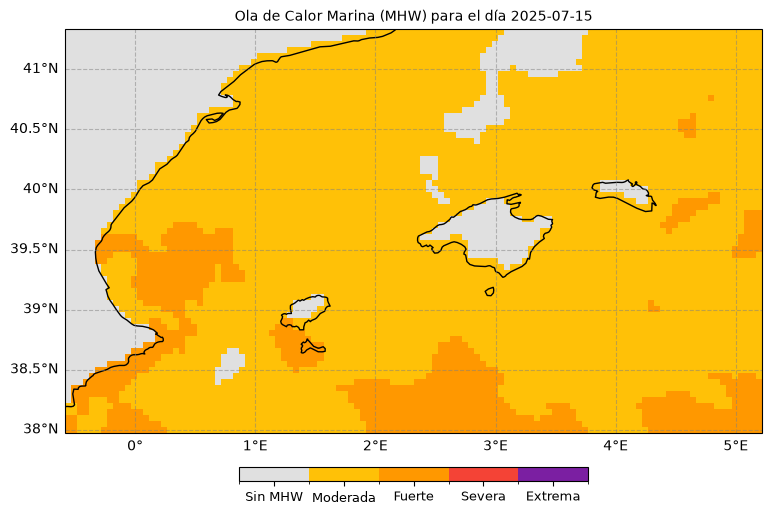

In [21]:
doi = "2025-07-15"
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# (land overlay keeps coastlines clean)
ax.add_feature(cfeature.LAND, facecolor="#e6e6e6", edgecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5, edgecolor="gray")

# select our data
plot_obj = categories_2025.sel(time="2025-07-15").plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    shading="nearest"
)
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False
ax.set_title((f'Ola de Calor Marina (MHW) para el día {doi}'), fontsize=10 , y=1)
cax = ax.inset_axes([0.25, -0.12, 0.50, 0.035])
cbar = fig.colorbar(plot_obj, cax=cax, orientation="horizontal", ticks=[0, 1, 2, 3, 4])
cbar.ax.tick_params(labelsize=9)
cbar.ax.set_xticklabels(['Sin MHW', 'Moderada', 'Fuerte', 'Severa', 'Extrema'])
plt.show()

#### Agrupación Mensual

Si bien la visualización diaria revela la variación detallada a través del tiempo, las métricas mensuales agregadas nos ayudan a rastrear la duración del estrés térmico localizadas.
Un indicador clave en el [portal My Ocean Health](https://myoceanhealth.marine.copernicus.eu/en) es el recuento mensual de días con olas de calor marinas fuertes o superiores (categoría $\ge 2$).<br>

Recategorizamos nuestro conjunto de datos diarios de 2025 por mes (julio, agosto y septiembre) y sumamos las instancias en las que las categorías de MHW cumplen o superan la **Categoría 2** para cada uno de ellos.

In [22]:
monthly_condition = (categories_2025 >= 2)
monthly_strong_days = monthly_condition.resample(time="1MS").sum(dim="time")
monthly_strong_days

<xarray.DataArray 'analysed_sst' (time: 3, latitude: 67, longitude: 116)> Size: 187kB
array([[[16, 15, 14, ..., 18, 17, 16],
        [16, 16, 14, ..., 17, 17, 18],
        [17, 17, 14, ..., 17, 17, 17],
        ...,
        [ 0,  0,  0, ...,  4,  4,  4],
        [ 0,  0,  0, ...,  4,  4,  4],
        [ 0,  0,  0, ...,  5,  4,  4]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  4,  3,  2],
        [ 0,  0,  0, ...,  2,  3,  3],
        [ 0,  0,  0, ...,  1,  1,  2]],

       [[ 0,  0,  0, ...,  3,  1,  2],
        [ 0,  0,  0, ...,  3,  1,  1],
        [ 0,  0,  0, ...,  2,  1,  2],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]]], shape=(3, 67, 116))
Coordinates:
  * time       (time) datetime64[ns] 24B 2025-07-01 2025-08-01 2025-09-01
  * latitude   (latitude) float32 268B 38.0 38.05 38.1 ... 41.21 41.26 41.31
  * longitude  (longitude) float32 464B -0.5589 -0.5088 -0.4588 ... 5.146 5.196
    quantile   float64 8B 0.9

Para visualizar esta acumulación mensual, creamos una rampa de color continua personalizada que va del blanco al rojo cereza intenso:

In [23]:
cherry_colors = ["#ffffff", "#d36165", "#95000ae5"]  
cherry_cmap = mcolors.LinearSegmentedColormap.from_list("WhiteToCherry", cherry_colors)

Por último, presentamos un mapa comparativo que ilustra la exposición mensual a las olas de calor en el Mar Balear:

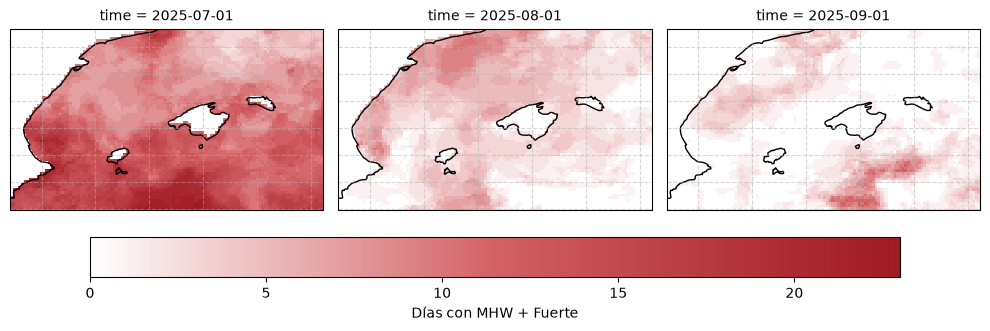

In [24]:
# situamos los mapas lado a lado
g = monthly_strong_days.plot.pcolormesh(
    col="time",
    transform=ccrs.PlateCarree(),
    subplot_kws={"projection": ccrs.PlateCarree()},
    cmap = cherry_cmap ,
    cbar_kwargs={"label": "Días con MHW + Fuerte", "orientation": "horizontal", "pad": 0.1}
)

# agregamos capas que facilitan la ubicacion de detalles
for ax in g.axs.flat:
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.5)

plt.show()

<hr>

<a id="example4"></a>

## 3️⃣ : Ahora es tu turno 💪

Ya que hemos dominado el análisis de la temperatura superficial del mar en el Mar Balear, podemos aplicar el mismo marco analítico a otros ecosistemas marinos críticos en toda España.

Para perfeccionar tus habilidades, te proponemos explorar la Costa de Galicia. Las  ensenadas costeras (rías) protegidas, producen la mayor parte de los mejillones cultivados en España (*Mytilus galloprovincialis*) y albergan criaderos de mariscos de renombre mundial.<br>
Las altas temperaturas de la superficie del mar alteran la dinámica de las floraciones de algas tóxicas (mareas rojas), lo que provoca cierres prolongados de las zonas de pesca y pérdidas económicas para la maricultura local.<br>

Para explorar las MHV en el área:<br>

- Define tu área de interés: Visita [bboxfinder.com](https://bboxfinder.com/) para seleccionarla.
- Define el conjunto de datos de la temperatura superficial del **mar Atlántico**: Consulta el conjunto de datos reprocesados ​​de alta resolución del Atlántico (`SST_ATL_SST_L4_REP_OBSERVATIONS_010_026`) del catálogo Copernicus Marine.
- Recalcula tu línea base: la base de referencia de 30 años ($T_{\text{media}}$, $T_{90}$ y $\Delta T$) sobre el área de interés sobre el Atlántico.
- Extrae los datos del verano de 2025: puedes definir los meses de julio, agosto y septiembre.
- Genera visualizaciones diarias y mensuales de MHW:
     Puedes representar las categorías de MHW para el día central de cada mes (15 de julio, 15 de agosto y 15 de septiembre).
- Y finalmente, generar un mapa de 3 paneles que muestre el recuento mensual de días con calentamiento medio de montaña (MHW) fuerte o superior ($\ge\text{Cat. II}$) para evaluar el estrés térmico.

<hr>

<a id="example5"></a>

## 4️⃣ : Conclusión

En este tutorial, hemos complementado la brecha entre las herramientas de visualización web y el análisis oceanográfico reproducible de alta resolución. Al ir más allá de las ventanas de visualización predeterminadas de una plataforma, demostramos cómo a través de **Python**, la **API de CopernicusMarine** y `xarray` facilitan a los expertos explorar mediante los productos de **Copernicus Marine Data Store** para estudios de impacto localizados. Ésto también nos permite acceder a los datos e integrarlos en nuestra metodología objetivo.<br>

Ya sea para evaluar la temperatura superficial del mar en el Mediterráneo o para rastrear las alteraciones a lo largo de una costa, ésta plataforma de código abierto proporciona las herramientas fundamentales para monitorear los impactos del calentamiento oceánico en los ecosistemas marinos de España.

#### Referencias

| Categoría | Documentación | Acceso |
| :--- | :--- | :--- |
| **Copernicus Marine** | **Copernicus Marine Data Store** | Versión Web del catálogo. [Acceso al portal](https://data.marine.copernicus.eu/products) |
| **Copernicus Marine Toolbox** | Documentación oficial del `copernicusmarine` Python API y CLI.| [Leer](https://help.marine.copernicus.eu/en/collections/9110377-copernicus-marine-toolbox) |
| **My Ocean Health Portal** | Visualización interactiva de indicadores oceánicos| [Portal](https://myoceanhealth.marine.copernicus.eu/en) |
| **Metodología de cálculo para MHW** | **Hobday et al. (2016)** | *A hierarchical approach to defining marine heatwaves* (Journal of Marine Systems) [Acceso al Artículo](https://passage.phys.ocean.dal.ca/~olivere/docs/Hobdayetal_2016_PO_HierarchMHWDefn.pdf)|
| **Python Toolkits** | **Documentación de `xarray`** | Arrays multi-dimensionales, lazy loading y remuestreo espacial . [Leer](https://docs.xarray.dev/en/stable/) |
| **`Cartopy` Documentation** | Cartografía para Python | [Leer](https://scitools.org.uk/cartopy/docs/latest/) |

`Happy EO coding :)!` 🛰️

<hr>

&copy; 2026 thriveGEO GmbH
